In [ ]:
!pip install tensorboardX

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 1.1 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/AndreasMadsen/stable-nalu.git

Cloning into 'stable-nalu'...
remote: Enumerating objects: 3003, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 3003 (delta 57), reused 109 (delta 55), pack-reused 2892 (from 1)
Receiving objects: 100% (3003/3003), 14.82 MiB | 22.18 MiB/s, done.
Resolving deltas: 100% (2271/2271), done.


In [ ]:
cd stable-nalu

/content/stable-nalu


In [ ]:
!python setup.py develop

/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/dist.py:261: UserWarning: Unknown distribution option: 'test_suite'
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/dist.py:261: UserWarning: Unknown distribution option: 'tests_require'
  warnings.warn(msg)
running develop
/usr/local/lib/python3.12/dist-packages/setuptools/command/develop.py:41: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` and ``easy_install``.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://github.com/pypa/setuptools/issues/917 for details.
        ********************************************************************************

!!
  easy_install.initialize_options(self)
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDepre

In [ ]:
!pip install torchdiffeq


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchdiffeq import odeint

import pandas as pd
import numpy as np

import scipy

In [ ]:
from stable_nalu.layer.re_regualized_linear_nac import ReRegualizedLinearNACLayer
from stable_nalu.layer.re_regualized_linear_nalu import ReRegualizedLinearNALULayer

/content/stable-nalu/stable_nalu/functional/gumbel.py:26: SyntaxWarning: invalid escape sequence '\i'
  tau: the temperature used, must be tau \in (0, \infty]. tau < 1
/content/stable-nalu/stable_nalu/layer/nac.py:13: SyntaxWarning: invalid escape sequence '\h'
  Asumming \hat{w} and \hat{m} are sampled from a uniform


In [ ]:
SEED=8#10#9 2,3,4
rnd=np.random.default_rng(1)
torch.manual_seed(SEED)

In [ ]:
kwargs_nalu={'eps': 1e-07,'nac_oob': 'clip','regualizer_shape': 'linear','regualizer_z': 0,'mnac_epsilon': 0,'nalu_bias': False,'nalu_two_nac': True,'nalu_two_gate': False,'nalu_mul': 'mnac','nalu_gate': 'normal'}
kwargs_nac={'eps': 1e-07,'nac_oob': 'clip','regualizer_shape': 'linear','regualizer_z': 0,'mnac_epsilon': 0,'nalu_bias': False,'nalu_two_nac': False,'nalu_two_gate': False,'nalu_mul': 'normal','nalu_gate': 'normal'}

In [ ]:
class MyModel(nn.Module):
    def __init__(self, in_feats,h_feats, out_feat):
        super(MyModel, self).__init__()
        self.net0=nn.Linear(in_feats , h_feats*3,bias=False)
        self.net1=nn.Linear(h_feats*3 , h_feats,bias=False)
        # # self.net1_1=nn.Linear(h_feats*2 , h_feats*2,bias=False)
        self.leaKyrelu=torch.nn.LeakyReLU(0.1)
        self.net_nac=ReRegualizedLinearNACLayer(in_features=h_feats,out_features=h_feats,**kwargs_nac)
        self.net_nalu=ReRegualizedLinearNALULayer(in_features=h_feats,out_features=out_feat,**kwargs_nalu)
    def forward(self,t,inputs_):
        # h=inputs_.float()
        inputs_ = inputs_.reshape(1,-1)
        h=self.net0(inputs_.float())
        h=self.leaKyrelu(h)
        # # h=self.net1_1(h)
        # # h=self.leaKyrelu(h)
        h=self.net1(h)
        h=self.leaKyrelu(h)
        # h=self.net_nac(h)
        h=self.net_nalu(h)
        return h.double()
    def reset_parameters(self):
        torch.nn.init.xavier_uniform(self.net0.weight)
        torch.nn.init.xavier_uniform(self.net1.weight)
        # # torch.nn.init.xavier_uniform(self.net1_1.weight)
        self.net_nalu.reset_parameters()
        # self.net_nac.reset_parameters()
    def regualizer(self):
        self.net_nalu.regualizer()
        self.net_nac.regualizer()

In [ ]:
tf=14
tf_learn=3.5
N_t_train=35
N_t=int((35*tf/tf_learn))

alpha=1.5
beta=1
gamma=3
delta=1


x0=1
y0=1

X0=np.array([x0, y0])


t=torch.tensor(np.linspace(0, tf, N_t))
t_learn=torch.tensor(np.linspace(0, tf_learn, N_t_train))

In [ ]:
import scipy
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

soln_arr=torch.tensor(scipy.integrate.odeint(pred_prey_deriv, X0, t, args=(alpha, beta, delta, gamma))).float()


In [ ]:
X0=torch.unsqueeze((torch.Tensor(np.transpose(X0))), 0)
X0.requires_grad=True

In [ ]:
# ----------------------------
# 1. Neural ODE function f(x,t)
# # ----------------------------
# class ODEFunc(nn.Module):
#     def __init__(self, hidden_dim=64):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(2, hidden_dim),
#             nn.Tanh(),
#             nn.Linear(hidden_dim, hidden_dim),
#             nn.Tanh(),
#             nn.Linear(hidden_dim, 2)
#         )

#     def forward(self, t, state):
#         # state: [batch, 2] = (x, y)
#         return self.net(state)


# ----------------------------
# 2. Neural ODE wrapper model
# ----------------------------
class NeuralODE(nn.Module):
    def __init__(self, func):
        super().__init__()
        self.func = func

    def forward(self, y0, t):
        # integrates from t[0] to t[-1]
        out = odeint(self.func, y0, t, method='rk4')
        # shape: [time, batch, 2]
        return out


# ----------------------------
# 3. Example: synthetic Lotka-Volterra data (if needed)
# ----------------------------
# def lotka_volterra_true(t, state, a=1.5, b=1.0, c=3.0, d=1.0):
#     x, y = state[..., 0], state[..., 1]
#     dx = a*x - b*x*y
#     dy = -c*y + d*x*y
#     return torch.stack([dx, dy], dim=-1)


# ----------------------------
# 4. Training setup
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

func = MyModel(2,2,2).to(device)#ODEFunc()
func.reset_parameters()
model = NeuralODE(func).to(device)



# ----------------------------
# 5. Dummy data (replace with your dataset)
# ----------------------------
# T = 140
# t = torch.linspace(0, 10, T).to(device)

# y0 = torch.tensor([1.0, 1.0]).to(device)

# with torch.no_grad():
#     true_traj = odeint(
#         lotka_volterra_true,
#         y0,
#         t,
#         method='rk4'
#     ).to(device)  # [T, 2]

# # add batch dimension
# true_traj = true_traj.unsqueeze(1)  # [T, 1, 2]

/tmp/ipykernel_11326/1749148975.py:23: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  torch.nn.init.xavier_uniform(self.net0.weight)
/tmp/ipykernel_11326/1749148975.py:24: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  torch.nn.init.xavier_uniform(self.net1.weight)


In [ ]:
import os
os.mkdir('../models')

In [ ]:
optimizer = optim.RMSprop(model.parameters(), lr=0.01)

In [ ]:
best_loss = np.inf
loss_fn = torch.nn.MSELoss()
for epoch in range(10000):
    optimizer.zero_grad()

    pred_traj = model(X0, t_learn)  # [T, 1, 2]

    # loss_train=torch.mean(torch.square(pred[:, 0, :]-soln_arr))
    loss = loss_fn(pred_traj[:,0,:], soln_arr[:N_t_train])

    loss.backward()
    optimizer.step()

    with torch.no_grad():

        pred_test=model(X0, t)[N_t_train:]

        test_loss=loss_fn(soln_arr[N_t_train:],pred_test[:,0,:]).item()
        if test_loss<best_loss:
            best_loss=test_loss
            torch.save(model,f'../models/modelr_{epoch}.pt')
            torch.save(model.state_dict(), f"../models/modelr_weights_{epoch}.pt")

            print(f'saved at {epoch} with error {loss}, {best_loss}')
    # loss_list_test.append(torch.mean(torch.square(pred_test[N_t_train:,0, :]-soln_arr[N_t_train:, :])).detach().cpu())

saved at 0 with error 4.179872989654541, 466.04913330078125
saved at 1 with error 3.908921241760254, 27.17643165588379
saved at 10 with error 3.359477996826172, 27.095388412475586
saved at 11 with error 3.3484842777252197, 24.908397674560547
saved at 12 with error 3.3378405570983887, 23.701383590698242
saved at 13 with error 3.327094078063965, 22.18253517150879
saved at 14 with error 3.315863847732544, 20.771484375
saved at 15 with error 3.3036019802093506, 19.249834060668945
saved at 16 with error 3.2896087169647217, 17.62997817993164
saved at 17 with error 3.2731590270996094, 15.926661491394043
saved at 18 with error 3.2540252208709717, 14.253003120422363
saved at 19 with error 3.2331995964050293, 12.779878616333008
saved at 20 with error 3.2126641273498535, 11.63216495513916
saved at 21 with error 3.193857431411743, 10.796342849731445
saved at 22 with error 3.176769256591797, 10.143577575683594
saved at 23 with error 3.160557508468628, 9.529621124267578
saved at 24 with error 3.1443

In [ ]:
epoch

9999

In [ ]:
test_loss

2.1972873210906982

evaluation on best model

In [ ]:
net = MyModel(2,2,2).to(device)
node = NeuralODE(net).to(device)
node.load_state_dict(torch.load('../models/modelr_weights_4972.pt'))

<All keys matched successfully>

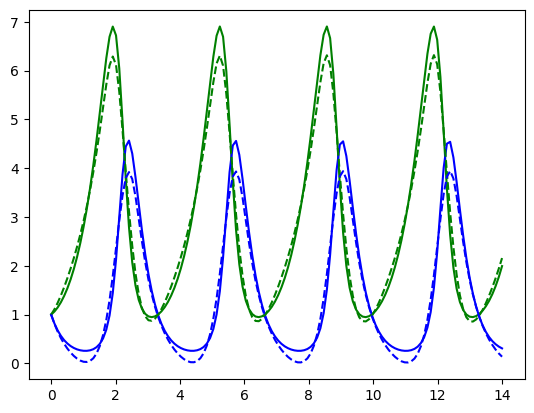

In [ ]:
import matplotlib.pyplot as plt
pred = node(X0, t)

plt.plot(t, soln_arr[:, 0].detach(), color='g')
plt.plot(t, soln_arr[:, 1].detach(), color='b')
plt.plot(t, pred[:,0, 0].detach(), linestyle='dashed', color='g')
plt.plot(t, pred[:,0, 1].detach(), linestyle='dashed', color='b')

In [ ]:
soln_arr.shape

torch.Size([140, 2])

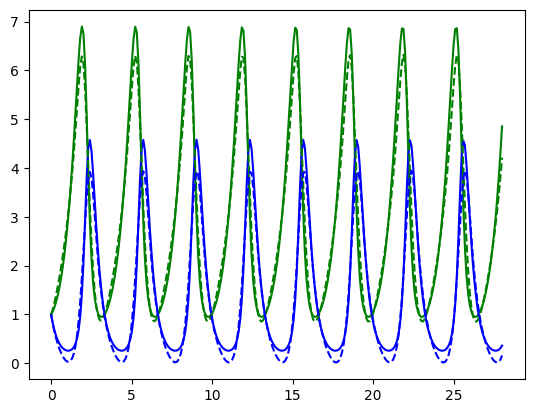

In [ ]:
import matplotlib.pyplot as plt

t_extrapolation=torch.tensor(np.linspace(0, 28, 280))
pred = node(X0, t_extrapolation)

soln_arr=torch.tensor(scipy.integrate.odeint(pred_prey_deriv, X0.detach().numpy()[0], t_extrapolation, args=(alpha, beta, delta, gamma))).float()

plt.plot(t_extrapolation, soln_arr[:, 0].detach(), color='g')
plt.plot(t_extrapolation, soln_arr[:, 1].detach(), color='b')
plt.plot(t_extrapolation, pred[:,0, 0].detach(), linestyle='dashed', color='g')
plt.plot(t_extrapolation, pred[:,0, 1].detach(), linestyle='dashed', color='b')

In [ ]:
t=torch.tensor(np.linspace(0, 35, 70))
soln_arr = torch.from_numpy(scipy.integrate.odeint(pred_prey_deriv, [1.0,1.0], t, args=(alpha, beta, delta, gamma)))

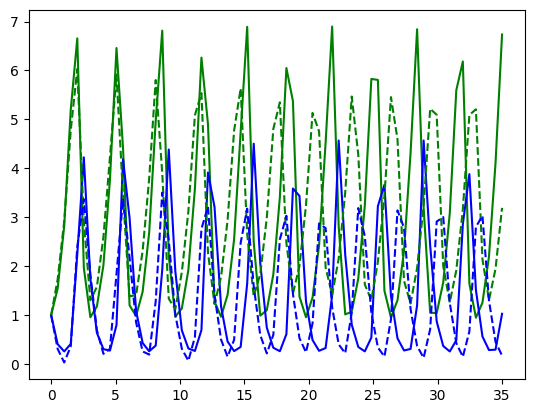

In [ ]:
X0_0 = torch.tensor([[1.0, 1.0]])
pred = node(X0_0, t)

plt.plot(t, soln_arr[:, 0].detach(), color='g')
plt.plot(t, soln_arr[:, 1].detach(), color='b')
plt.plot(t, pred[:,0, 0].detach(), linestyle='dashed', color='g')
plt.plot(t, pred[:,0, 1].detach(), linestyle='dashed', color='b')